In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_PATH = '../outputs'
FC_THRESH = 1.0
PADJ_THRESH = 0.05
MAX_NEGLOG10_P = 20
MAX_FOLD_CHANGE = 8

# Load gene coordinates
gene_allelic_file = pd.read_csv("../data/gene_coordinates.txt", sep="\t")
gene_allelic_file['Chromosome/scaffold name'] = (
    gene_allelic_file['Chromosome/scaffold name'].replace({'X': '23', 'Y': '24'})
)
gene_allelic_file['Chromosome/scaffold name'] = pd.to_numeric(gene_allelic_file['Chromosome/scaffold name'])
gene_allelic_file = gene_allelic_file[
    (gene_allelic_file['Chromosome/scaffold name'] >= 1) &
    (gene_allelic_file['Chromosome/scaffold name'] <= 24)
]
gene_allelic_file['Chromosome/scaffold name'] = gene_allelic_file['Chromosome/scaffold name'].astype(int)
gene_coords = gene_allelic_file[
    ['Gene name', 'Chromosome/scaffold name', 'Gene start (bp)', 'Gene end (bp)']
].drop_duplicates('Gene name')

# Define hotspots
hotspots = [
    {'label': 'CCND3',    'deseq_file': '../outputs/output_files_ccnd3/results_w_dfci.csv',      'chrom': 6,  'start': 39000000, 'end': 55000000},
    {'label': 'CCNE1',    'deseq_file': '../outputs/output_files_ccne1/results_w_dfci.csv',      'chrom': 19, 'start': 27000000, 'end': 34000000},
    {'label': 'CDK4-MDM2','deseq_file': '../outputs/output_files_cdk4-mdm2/results_w_dfci.csv', 'chrom': 12, 'start': 53000000, 'end': 75000000},
    {'label': 'MYC',      'deseq_file': '../outputs/output_files_myc/results_w_dfci.csv',        'chrom': 8,  'start': 99000000, 'end': 137000000},
    {'label': 'TP53',     'deseq_file': '../outputs/output_files_tp53/results_w_dfci.csv',       'chrom': 17, 'start': 7000000,  'end': 22000000},
]

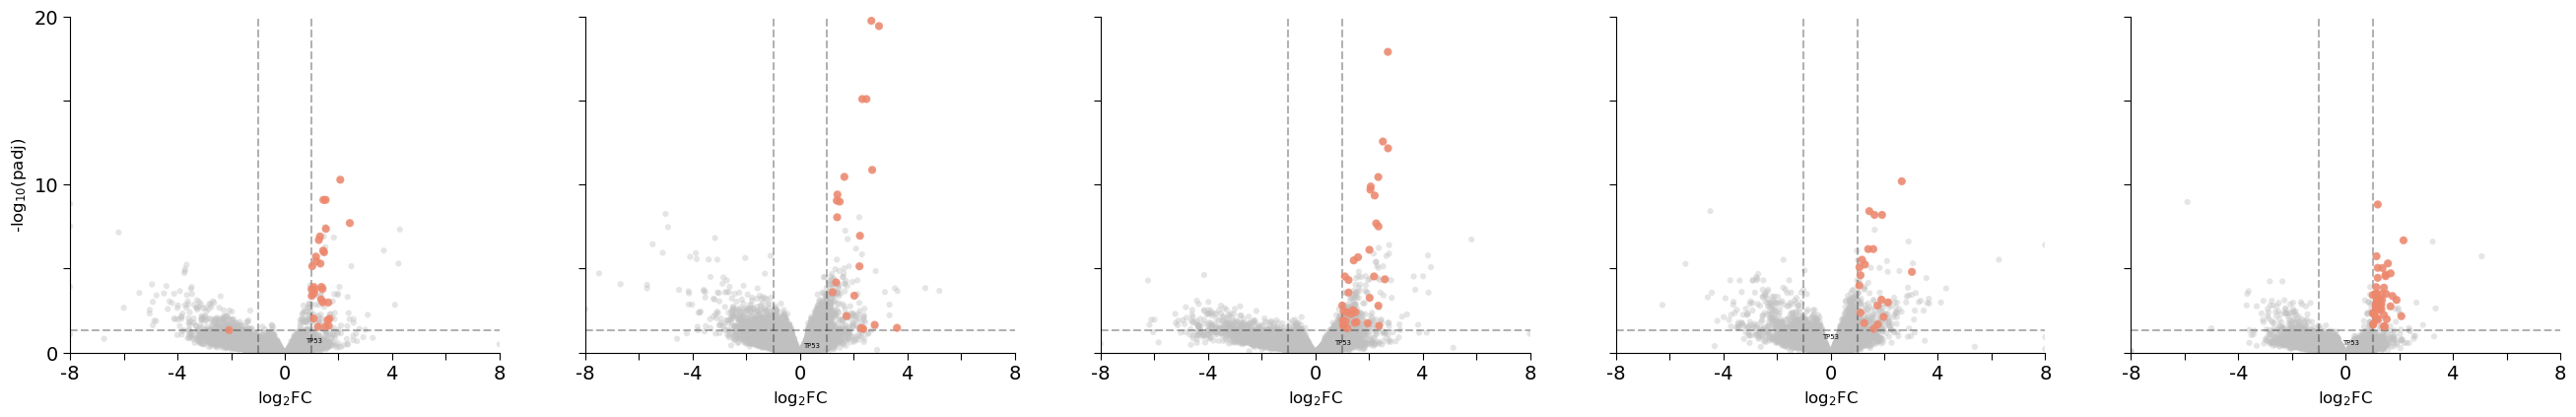

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(26, 4))
plt.tight_layout(rect=[0, 0, 1, 1])
plt.subplots_adjust(wspace=0.2)

for i, (hotspot, ax) in enumerate(zip(hotspots, axes)):

    df = pd.read_csv(hotspot['deseq_file'])
    df = df.merge(gene_coords, left_on='gene_name', right_on='Gene name', how='left')
    df = df.dropna(subset=['log2FoldChange', 'padj', 'Chromosome/scaffold name'])

    # Exclude genes above the p-value cap
    df['neglog10_padj'] = -np.log10(df['padj'])
    df = df[df['neglog10_padj'] <= MAX_NEGLOG10_P].copy()
    # Clip fold change
    df['log2FoldChange'] = np.clip(df['log2FoldChange'], -MAX_FOLD_CHANGE, MAX_FOLD_CHANGE)

    # Background (all genes)
    ax.scatter(df['log2FoldChange'], df['neglog10_padj'],
            c='#c0c0c0', s=20, edgecolors='none', alpha=0.4, zorder=2, rasterized=True)

    # filter to FC threshold for highlighted genes only
    df_fc = df[np.abs(df['log2FoldChange']) >= FC_THRESH].copy()

    in_region_sig = (
        (df_fc['Chromosome/scaffold name'] == hotspot['chrom']) &
        (df_fc['Gene start (bp)'] >= hotspot['start']) &
        (df_fc['Gene start (bp)'] <= hotspot['end']) &
        (df_fc['neglog10_padj'] >= -np.log10(PADJ_THRESH))
    )

    in_up = df_fc[ in_region_sig & (df_fc['log2FoldChange'] > 0)]
    in_dn = df_fc[ in_region_sig & (df_fc['log2FoldChange'] < 0)]

    # Highlighted genes: in clustered SV region + significant
    ax.scatter(in_up['log2FoldChange'], in_up['neglog10_padj'],
               c='#ee876cff', s=35, edgecolors='none', alpha=0.85, zorder=3)
    ax.scatter(in_dn['log2FoldChange'], in_dn['neglog10_padj'],
               c='#ee876cff', s=35, edgecolors='none', alpha=0.85, zorder=3)
    
    # annotate specific genes
    #genes_to_label = ['MYC', 'CCND3', 'CCNE1', 'CDK4', 'TP53']
    genes_to_label = ['TP53']
    #genes_to_label = ['']

    for _, row in df[df['gene_name'].isin(genes_to_label)].iterrows():
        ax.annotate(row['gene_name'],
                    xy=(row['log2FoldChange'], row['neglog10_padj']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=5)

    # Threshold lines
    ax.axvline( FC_THRESH, color='black', linestyle='--', alpha=0.3)
    ax.axvline(-FC_THRESH, color='black', linestyle='--', alpha=0.3)
    ax.axhline(-np.log10(PADJ_THRESH), color='black', linestyle='--', alpha=0.3)


    # y-axis
    ax.set_ylim(0, MAX_NEGLOG10_P)
    ax.spines['left'].set_bounds(0, MAX_NEGLOG10_P)

    y_ticks = np.arange(0, MAX_NEGLOG10_P + 1, 5)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(int(t)) if j % 2 == 0 else '' for j, t in enumerate(y_ticks)])

    # x-axis
    fc_abs_max = math.ceil(df['log2FoldChange'].abs().max())
    ax.set_xlim(-fc_abs_max, fc_abs_max)
    x_ticks = np.arange(-fc_abs_max, fc_abs_max + 1, 2)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(int(t)) if j % 2 == 0 else '' for j, t in enumerate(x_ticks)])
    ax.set_xlabel('log$_2$FC', fontsize=12)
    ax.spines['bottom'].set_bounds(-fc_abs_max, fc_abs_max)


    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if i == 0:
        ax.set_ylabel('-log$_{10}$(padj)', fontsize=12)
    else:
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelleft=False)
    ax.tick_params(labelsize=14, length=5)

fig.axes[-1].set_visible(False) if len(fig.axes) > 5 else None

plt.savefig(os.path.join(OUTPUT_PATH, 'volcano_all_hotspots_w_dfci.pdf'), dpi=400, bbox_inches='tight')
plt.show()